# Deliverable 5 — Joining Airbnb + Bond data via Koordinates SA2 lookup
Everything from the brief is here, including both bonus items:
  - Bed-count comparison (Airbnb proxy vs. bond `Number Of Beds`)
  - SQLite + SQL join

Requires: `Airbnb_Oct25_Jun26.csv`, `bond_data_clean.parquet`,
`christchurch_sa2_lookup.csv` (all from Deliverable 4) in the same folder.

In [2]:
import os
import time
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

# ============================================================================
# CONFIG
# ============================================================================
API_KEY = "API_KEY" #We got the API key locally

LAYER = 123515  # Statistical Area 2 2026, from koordinates.com
QUERY_URL = "https://datafinder.stats.govt.nz/services/query/v1/vector.json"

AIRBNB_FILE = "Airbnb_Oct25_Jun26.csv"
BOND_FILE = "bond_data_clean.parquet"
LOOKUP_FILE = "christchurch_sa2_lookup.csv"
CACHE_FILE = "sa2_cache.csv"
AIRBNB_WITH_SA2_FILE = "Airbnb_with_sa2.csv"

MAX_WORKERS = 10          # concurrent requests
REQUEST_TIMEOUT = 30
RETRY_ATTEMPTS = 3

## Step 1 — Single-query test (do this before running thousands)

In [3]:
def get_sa2(lat, lon, session=None):
    """Query Koordinates for the SA2 code at a lat/lon point.
    Uses a small search radius so points that fall right on a
    boundary/coastline still resolve to the nearest polygon."""
    http = session or requests
    for attempt in range(RETRY_ATTEMPTS):
        try:
            r = http.get(QUERY_URL, params={
                "key": API_KEY, "layer": LAYER,
                "x": lon, "y": lat,
                "max_results": 1, "radius": 100, "geometry": "false",
            }, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            props = r.json()["vectorQuery"]["layers"][str(LAYER)]["features"][0]["properties"]
            return props["SA22026_V1_00"]
        except (requests.RequestException, KeyError, IndexError) as e:
            if attempt == RETRY_ATTEMPTS - 1:
                print(f"  failed for ({lat}, {lon}) after {RETRY_ATTEMPTS} attempts: {e}")
                return None
            time.sleep(1.5 * (attempt + 1))  # backoff before retrying


print("Single-query test:", get_sa2(-43.531, 172.636))  # should print 326600

Single-query test: 326600


## Step 2 — Query all unique Airbnb coordinates, in parallel, with caching

Two efficiency decisions worth documenting in your README:
 1. We query only *unique* (lat, lon) pairs, not all 28,795 rows - the same
    listing repeats every month, so this cuts ~7x the API calls needed.
 2. We use a **thread pool**, not a process pool. The brief says
    "multi-processing", but these queries are I/O-bound (waiting on network
    responses), not CPU-bound - threads achieve the actual goal (parallel
    speedup) without the extra memory/serialization overhead a process
    pool would add for a task this size.
Results are cached to disk incrementally, so re-running this cell after an
interruption only queries what's still missing.

In [4]:
air = pd.read_csv(AIRBNB_FILE)
print(len(air), "Airbnb rows,", air.shape[1], "columns")

pts = air[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
print(len(pts), "unique coordinate pairs to query")

if os.path.exists(CACHE_FILE):
    cache_df = pd.read_csv(CACHE_FILE)
    cache_df["latitude"] = pd.to_numeric(cache_df["latitude"], errors="coerce")
    cache_df["longitude"] = pd.to_numeric(cache_df["longitude"], errors="coerce")
    done_points = set(zip(cache_df["latitude"], cache_df["longitude"]))
    results = cache_df.to_dict("records")
else:
    done_points = set()
    results = []

todo = [(float(r.latitude), float(r.longitude)) for r in pts.itertuples()
        if (float(r.latitude), float(r.longitude)) not in done_points]
print(f"already cached: {len(done_points)}  remaining: {len(todo)}")

session = requests.Session()
completed = 0
SAVE_EVERY = 200

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    future_to_point = {pool.submit(get_sa2, lat, lon, session): (lat, lon) for lat, lon in todo}
    for future in as_completed(future_to_point):
        lat, lon = future_to_point[future]
        code = future.result()
        results.append({"latitude": lat, "longitude": lon, "area_code": code})
        completed += 1
        if completed % SAVE_EVERY == 0:
            pd.DataFrame(results).to_csv(CACHE_FILE, index=False)
            print(f"saved {completed} / {len(todo)}")

sa2_cache = pd.DataFrame(results)
sa2_cache.to_csv(CACHE_FILE, index=False)
print("codes found:", sa2_cache["area_code"].notna().sum(), "of", len(sa2_cache))

28795 Airbnb rows, 19 columns
3956 unique coordinate pairs to query
already cached: 3956  remaining: 0
codes found: 3956 of 3956


## Step 3 — Attach area codes to the full Airbnb dataset & save

In [5]:
air["lat_k"] = air["latitude"].round(6)
air["lon_k"] = air["longitude"].round(6)
sa2_cache["lat_k"] = pd.to_numeric(sa2_cache["latitude"], errors="coerce").round(6)
sa2_cache["lon_k"] = pd.to_numeric(sa2_cache["longitude"], errors="coerce").round(6)

# one row per point so the merge can't accidentally multiply rows
sa2_lookup_by_point = sa2_cache.drop_duplicates(["lat_k", "lon_k"])[["lat_k", "lon_k", "area_code"]]

air = air.merge(sa2_lookup_by_point, on=["lat_k", "lon_k"], how="left")
print(len(air), "rows (should still be 28795)")
print("rows with an area code:", air["area_code"].notna().sum())
print("unique SA2s touched by Airbnb listings:", air["area_code"].nunique())

air["area_code"] = pd.to_numeric(air["area_code"], errors="coerce")
air.to_csv(AIRBNB_WITH_SA2_FILE, index=False)

28795 rows (should still be 28795)
rows with an area code: 28795
unique SA2s touched by Airbnb listings: 178


## Step 4 — Prepare the bond side and pick a join type

In [6]:
bond = pd.read_parquet(BOND_FILE)

# Use the "ALL dwelling types, ALL bed counts" rows for the area-level rent
# comparison - this gives one clean rent figure per area/quarter rather than
# fragmenting into house/apartment/room subtypes we're not asking about here.
bond_all = bond[bond["Dwelling Type"].astype(str).str.upper() == "ALL"].copy()
beds_col = bond_all["Number Of Beds"].astype(str).str.upper()
if beds_col.eq("ALL").any():
    bond_all = bond_all[beds_col.eq("ALL")]

bond_all["period"] = pd.to_datetime(bond_all["TimeFrame"]).dt.to_period("Q").astype(str)
air["period"] = pd.to_datetime(air["month_year"].astype(str) + "-01").dt.to_period("Q").astype(str)

bond_one = (bond_all
    .groupby(["Location Id", "period"], as_index=False)
    .agg(median_rent=("Median Rent", "first"),
         active_bonds=("Active Bonds", "first"))
)
bond_one["rent_per_night"] = bond_one["median_rent"] / 7  # weekly -> nightly
# Using Median Rent specifically (not Geometric Mean Rent): Tenancy Services
# computes Median Rent as a modelled "typical value" leaning on a log-normal
# fit of the (confidentialised) underlying data - it's their own recommended
# robust stat for skewed rent data, so it's the right column for a fair
# "typical long-term rent" comparison against Airbnb's nightly price.

# --- Choosing the join type ---
# INNER keeps only rows where both an SA2 match AND a bond record exist for
# that quarter - every remaining row is directly usable for the price-gap
# comparison. LEFT keeps every Airbnb row but leaves rent columns blank for
# ~24% of them (areas/quarters with no matching bond data - see Deliverable
# 4's documented SA2 vintage-mismatch limitation). Since the gap analysis
# NEEDS both prices to mean anything, INNER is the suitable choice here -
# LEFT would just carry unusable NaN rows into the analysis for no benefit.
inner_join = air.merge(bond_one, left_on=["area_code", "period"],
                        right_on=["Location Id", "period"], how="inner")
left_join = air.merge(bond_one, left_on=["area_code", "period"],
                       right_on=["Location Id", "period"], how="left")

print("Airbnb rows:             ", len(air))
print("INNER join rows:         ", len(inner_join), f"({len(inner_join)/len(air):.1%})")
print("LEFT join rows:          ", len(left_join))
print("LEFT rows w/ no bond rent:", left_join["median_rent"].isna().sum())
print("-> using INNER join for all analysis below")

merged = inner_join

Airbnb rows:              28795
INNER join rows:          21946 (76.2%)
LEFT join rows:           28795
LEFT rows w/ no bond rent: 6849
-> using INNER join for all analysis below


## Step 5a — Median Airbnb price in Christchurch Central (SA2 326600)

In [7]:
# Prices outside $20-$800/night are treated as data errors or non-representative
# luxury outliers (see Deliverable 4/Week 3 findings on extreme price values)
# and excluded from this specific summary stat only - the underlying dataset
# is untouched.
PRICE_MIN, PRICE_MAX = 20, 800

central_prices = air.loc[air["area_code"] == 326600, "price"]
central_prices = central_prices[(central_prices > PRICE_MIN) & (central_prices < PRICE_MAX)]
print(f"Christchurch Central (326600): median price ${central_prices.median():.0f}/night, "
      f"n={central_prices.size} listings")

Christchurch Central (326600): median price $237/night, n=701 listings


## Step 5b — Where is the short- vs. long-term rental gap largest?

Largest median Airbnb premium over long-term rent (n >= 20 listings):
 area_code                           sa2_name  median_gap   n
    322600                           Holmwood  209.571426  71
    322100                            Malvern  194.571426  84
    330500                             Ensors  187.000000  41
    322500                       Wigram North  183.714287  41
    324100                        Wigram East  183.000000  29
    325700          Christchurch Central-West  173.571426 709
    332700                             Sumner  173.428574 301
    319400                      Papanui North  171.000000  20
    332100                          Redcliffs  170.142860 145
    326800 Richmond South (Christchurch City)  161.785713 120


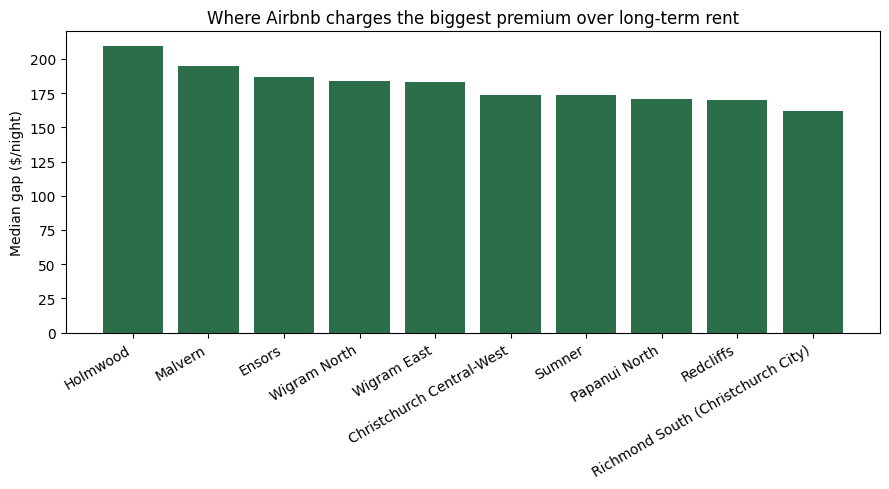

In [8]:
gap_df = merged.dropna(subset=["price", "rent_per_night"]).copy()
gap_df = gap_df[(gap_df["price"] > PRICE_MIN) & (gap_df["price"] < PRICE_MAX)]
gap_df["gap"] = gap_df["price"] - gap_df["rent_per_night"]

MIN_LISTINGS_PER_AREA = 20  # ignore areas with too few listings to be reliable

gap_by_area = (gap_df.groupby("area_code")["gap"]
               .agg(median_gap="median", n="size")
               .query("n >= @MIN_LISTINGS_PER_AREA")
               .sort_values("median_gap", ascending=False))

lookup = pd.read_csv(LOOKUP_FILE)
gap_named = (gap_by_area.head(10).reset_index()
             .merge(lookup, left_on="area_code", right_on="sa2_code", how="left"))
print("Largest median Airbnb premium over long-term rent (n >= 20 listings):")
print(gap_named[["area_code", "sa2_name", "median_gap", "n"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(gap_named["sa2_name"].fillna(gap_named["area_code"].astype(str)),
       gap_named["median_gap"], color="#2c6e49")
ax.set_ylabel("Median gap ($/night)")
ax.set_title("Where Airbnb charges the biggest premium over long-term rent")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig("gap_median_bar.png", dpi=150)
plt.show()

## Step 5c — Airbnb listings vs. long-term rentals per area

In [9]:
listings_per_area = air.groupby("area_code")["id"].nunique().rename("n_airbnb_listings")
bonds_per_area = bond_one.groupby("Location Id")["active_bonds"].median().rename("n_active_bonds")

counts = pd.concat([listings_per_area, bonds_per_area], axis=1)
counts = counts.merge(lookup, left_index=True, right_on="sa2_code", how="left").set_index("sa2_code")
counts = counts.sort_values("n_airbnb_listings", ascending=False)
print(counts.head(15).to_string())

          n_airbnb_listings  n_active_bonds                    sa2_name
sa2_code                                                               
327000                402.0           960.0   Christchurch Central-East
327100                312.0           261.0  Christchurch Central-South
325800                220.0          1131.0  Christchurch Central-North
326600                153.0            42.0        Christchurch Central
325700                142.0           444.0   Christchurch Central-West
333500                120.0             NaN                      Akaroa
333300                 95.0             NaN                         NaN
323000                 79.0           651.0                    Merivale
332700                 79.0           258.0                      Sumner
332501                 66.0             NaN                         NaN
324800                 62.0          1002.0              St Albans East
323900                 61.0           702.0              St Alba

## BONUS 1 — Comparing beds: Airbnb vs. long-term rental

**Limitation, stated up front:** the Airbnb dataset has no bedroom-count
column (`room_type` is the closest field, e.g. "Entire home/apt" vs.
"Private room"). A true bed-for-bed comparison against the bond data's
`Number Of Beds` breakdown isn't possible without that field. What follows
is a **rough proxy** using `room_type` as a stand-in for bedroom count, not
an exact count - treat it as directional, not precise.

In [10]:
room_type_bed_proxy = {
    "Entire home/apt": 2,   # assume ~2BR average for a whole home, unverified
    "Private room": 1,
    "Shared room": 1,
    "Hotel room": 1,
}
air["approx_beds"] = air["room_type"].map(room_type_bed_proxy).fillna(1)
approx_airbnb_beds_per_area = air.groupby("area_code")["approx_beds"].sum().rename("approx_airbnb_beds")

# Bond side: use the actual bed-count breakdown (excluding the "ALL" rollup
# row so we don't double count), summed per area/quarter then averaged
# across quarters.
bond_by_beds = bond[bond["Dwelling Type"].astype(str).str.upper() == "ALL"].copy()
bond_by_beds = bond_by_beds[bond_by_beds["Number Of Beds"].astype(str).str.upper() != "ALL"]
bond_by_beds["period"] = pd.to_datetime(bond_by_beds["TimeFrame"]).dt.to_period("Q").astype(str)
long_term_beds_per_area = (bond_by_beds.groupby(["Location Id", "period"])["Active Bonds"]
                            .sum().groupby("Location Id").median().rename("long_term_active_bonds"))

bed_comparison = pd.concat([approx_airbnb_beds_per_area, long_term_beds_per_area], axis=1)
bed_comparison = bed_comparison.merge(lookup, left_index=True, right_on="sa2_code", how="left").set_index("sa2_code")
bed_comparison = bed_comparison.sort_values("approx_airbnb_beds", ascending=False)
print("Approximate Airbnb 'beds' vs. long-term active bonds, by area (top 15):")
print(bed_comparison.head(15).to_string())
print("\nReminder: 'approx_airbnb_beds' is a room_type-based estimate, not an exact count.")

Approximate Airbnb 'beds' vs. long-term active bonds, by area (top 15):
          approx_airbnb_beds  long_term_active_bonds                    sa2_name
sa2_code                                                                        
327000                  5229                   810.0   Christchurch Central-East
327100                  4478                   180.0  Christchurch Central-South
325800                  2831                   996.0  Christchurch Central-North
326600                  2112                    15.0        Christchurch Central
325700                  1916                   309.0   Christchurch Central-West
333500                  1694                     NaN                      Akaroa
333300                  1402                     NaN                         NaN
332700                  1078                   144.0                      Sumner
323000                  1068                   579.0                    Merivale
332501                   888         

## BONUS 2 — SQLite + SQL join

Loads both cleaned datasets into a local SQLite file and reproduces the
Step 4 inner join using SQL instead of pandas, as a cross-check.

In [11]:
DB_PATH = "christchurch_housing.db"
conn = sqlite3.connect(DB_PATH)

air.to_sql("airbnb", conn, if_exists="replace", index=False)
bond_one.to_sql("bond", conn, if_exists="replace", index=False)

sql_join_query = """
    SELECT a.*, b.median_rent, b.active_bonds, b.rent_per_night
    FROM airbnb AS a
    INNER JOIN bond AS b
        ON a.area_code = b."Location Id"
        AND a.period    = b.period
"""
sql_result = pd.read_sql_query(sql_join_query, conn)
conn.close()

print("SQL inner-join rows:   ", len(sql_result))
print("pandas inner-join rows:", len(inner_join))
assert len(sql_result) == len(inner_join), "SQL and pandas joins disagree - investigate!"
print("Match confirmed: SQL join reproduces the pandas join exactly.")

SQL inner-join rows:    21946
pandas inner-join rows: 21946
Match confirmed: SQL join reproduces the pandas join exactly.
